# 32. Solving Least Squares in Practice

**Part 5: Orthogonality, QR and Least Squares**

## Learning objectives

By the end of this lesson you will be able to:

1. State the **four** condition numbers of a least squares problem, and say why quoting one is
   not enough.
2. Explain the role of the **angle** $\theta$ between $\mathbf{b}$ and $\operatorname{range}(A)$,
   and measure it without knowing the answer.
3. Recognise when a $\kappa^2$ really is present in the **problem** rather than being an
   artefact of the normal equations.
4. Use the **SVD** and the **Moore-Penrose pseudoinverse**, and check the four conditions that
   define it.
5. Say what the **minimum norm** solution is, and that it is a choice rather than a consequence.
6. Compare normal equations, QR and SVD on measured evidence, including where the SVD is
   **worse**.
7. Apply **Tikhonov regularization** and locate a penalty with the **L-curve**.
8. Choose between truncation and damping, and say what each assumes.

## Prerequisites

Lesson 29 (the normal equations and the squared condition number). Lessons 30 and 31 (QR).
Lesson 19 (conditioning of a square system). The SVD is used here as a tool and built properly
in lesson 41.

---

## 1. One condition number is not enough

Lesson 29 measured that the normal equations lose twice the digits QR does, and left the
impression that $\kappa(A)$ governs everything. It does not.

**There are two things that can be perturbed** ($A$ and $\mathbf{b}$) **and two answers to
watch** ($\mathbf{x}$ and the residual $\mathbf{r}$), so there are four sensitivities, and they
do not move together.

Write $\theta$ for the angle between $\mathbf{b}$ and $\operatorname{range}(A)$, and

$$\eta = \frac{\|A\|\,\|\mathbf{x}\|}{\|A\mathbf{x}\|}$$

for how much of $A$'s size the solution actually uses. Then:

| perturb | watch | condition number |
|---|---|---|
| $\mathbf{b}$ | $\mathbf{x}$ | $\kappa / (\eta\cos\theta)$ |
| $\mathbf{b}$ | $\mathbf{r}$ | $1/\cos\theta$ |
| $A$ | $\mathbf{x}$ | $\kappa + \kappa^2\tan\theta/\eta$ |
| $A$ | $\mathbf{r}$ | $\kappa$ |

**The third row carries a $\kappa^2$**, and it is not an artefact of any algorithm. It is a
property of the problem.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import leastsquares as ls, qr
import numpy as np

rows, cols = 40, 6
A_c = ls.graded_design(rows, cols, 1e6, rng)

print("the same matrix, data placed at different angles to its range\n")
print(f"{'noise':>8} {'theta':>11} {'eta':>12} {'b -> x':>11} {'b -> r':>9} "
      f"{'A -> x':>11} {'A -> r':>11}")
for level in [1e-10, 1e-3, 1e-1, 1.0, 10.0]:
    b_c = (A_c @ rng.standard_normal(A_c.shape[1])
           + level * rng.standard_normal(A_c.shape[0]))
    info = ls.least_squares_conditioning(A_c, b_c)
    print(f"{level:>8.0e} {np.degrees(info['theta']):>9.4f} deg {info['eta']:>12.1f} "
          f"{info['b_to_x']:>11.2e} {info['b_to_r']:>9.3f} {info['A_to_x']:>11.2e} "
          f"{info['A_to_r']:>11.2e}")

print()
print("kappa(A) is 1e6 in every row, and the four columns range over seven orders")
print("of magnitude. the last one is the only one that equals kappa.")

the same matrix, data placed at different angles to its range

   noise       theta          eta      b -> x    b -> r      A -> x      A -> r
   1e-10    0.0000 deg          1.1    8.80e+05     1.000    1.00e+06    1.00e+06
   1e-03    1.4024 deg       1015.9    9.85e+02     1.000    2.51e+07    1.00e+06
   1e-01   42.2686 deg     206778.9    6.54e+00     1.351    5.40e+06    1.00e+06
   1e+00   63.6656 deg     221338.2    1.02e+01     2.254    1.01e+07    1.00e+06
   1e+01   61.2579 deg     226907.2    9.16e+00     2.080    9.04e+06    1.00e+06

kappa(A) is 1e6 in every row, and the four columns range over seven orders
of magnitude. the last one is the only one that equals kappa.


**Read the first two rows together.** With the data almost exactly in the range,
$\theta \approx 0$, perturbing $\mathbf{b}$ moves $\mathbf{x}$ by $\kappa$, exactly as for a
square system. Tilt the data by a degree and a half and that sensitivity **falls** by three
orders of magnitude while the sensitivity to $A$ **rises** by one. They move in opposite
directions.

**Why $\theta$ enters at all.** The residual is what the model cannot explain. When it is zero
the problem is a square system in disguise and nothing surprising happens. When it is large,
$A\mathbf{x}$ is a small part of $\mathbf{b}$, so a small change in $A$ swings the projection a
long way, and the swing is amplified twice: once to find the projection and once to solve for
$\mathbf{x}$. That is where the square comes from.

In [3]:
print("the angle is measurable without knowing the answer\n")
print(f"{'noise':>8} {'theta':>13} {'sin(theta)':>13} {'||r|| / ||b||':>15}")
for level in [1e-6, 1e-2, 1e-1, 1.0, 10.0]:
    b_a = (A_c @ rng.standard_normal(A_c.shape[1])
           + level * rng.standard_normal(A_c.shape[0]))
    theta = ls.angle_to_range(A_c, b_a)
    rel = ls.solve_qr(A_c, b_a).residual_norm / np.linalg.norm(b_a)
    print(f"{level:>8.0e} {np.degrees(theta):>11.5f} deg {np.sin(theta):>13.6f} "
          f"{rel:>15.6f}")
    assert abs(np.sin(theta) - rel) < 1e-9

print()
print("sin(theta) IS the relative residual, to nine digits. so theta costs one")
print("solve and nothing else, and it is the quantity to look at before deciding")
print("whether a least squares problem is hard.")

the angle is measurable without knowing the answer

   noise         theta    sin(theta)   ||r|| / ||b||
   1e-06     0.00018 deg      0.000003        0.000003
   1e-02     3.45818 deg      0.060320        0.060320
   1e-01    24.00320 deg      0.406788        0.406788
   1e+00    77.06431 deg      0.974622        0.974622
   1e+01    81.88669 deg      0.989991        0.989991

sin(theta) IS the relative residual, to nine digits. so theta costs one
solve and nothing else, and it is the quantity to look at before deciding
whether a least squares problem is hard.


**And computing $\theta$ needs one piece of care that is easy to miss.** The obvious formula
is $\theta = \arccos(\|P\mathbf{b}\|/\|\mathbf{b}\|)$, and it is catastrophically wrong
for a small angle, because the derivative of $\arccos$ is infinite at 1 and the argument is 1
to within roundoff.

In [4]:
print("arccos against arctan2, for the same angle\n")
print(f"{'relative residual':>19} {'arccos':>14} {'error in sin':>14} "
      f"{'arctan2':>14} {'error in sin':>14}")
worst_acos = worst_atan = 0.0
for level in [1e-11, 1e-9, 1e-7, 1e-5, 1e-3, 1.0]:
    b_t = (A_c @ rng.standard_normal(A_c.shape[1])
           + level * rng.standard_normal(A_c.shape[0]))
    proj = A_c @ ls.solve_qr(A_c, b_t).x
    resid = b_t - proj
    rel = np.linalg.norm(resid) / np.linalg.norm(b_t)
    by_acos = np.arccos(min(1.0, np.linalg.norm(proj) / np.linalg.norm(b_t)))
    by_atan = np.arctan2(np.linalg.norm(resid), np.linalg.norm(proj))
    err_acos = abs(np.sin(by_acos) - rel) / rel
    err_atan = abs(np.sin(by_atan) - rel) / rel
    worst_acos, worst_atan = max(worst_acos, err_acos), max(worst_atan, err_atan)
    print(f"{rel:>19.6e} {by_acos:>14.6e} {err_acos:>14.1e} "
          f"{by_atan:>14.6e} {err_atan:>14.1e}")

print()
print(f"the arccos form is wrong by up to {worst_acos:.0%} over this range, and arctan2")
print(f"by at most {worst_atan:.1e}. it is lesson 05's cancellation wearing a")
print("trigonometric hat: 1 - cos(theta) is theta^2/2, so recovering theta from")
print("a cosine near 1 loses half the digits and then some.")
assert worst_atan < 1e-10 < worst_acos
print()
print("nalib.leastsquares.angle_to_range uses arctan2 for exactly this reason.")

arccos against arctan2, for the same angle

  relative residual         arccos   error in sin        arctan2   error in sin
       3.113602e-11   0.000000e+00        1.0e+00   3.113602e-11        2.1e-16
       5.176573e-09   0.000000e+00        1.0e+00   5.176573e-09        1.6e-16
       6.686786e-07   6.688945e-07        3.2e-04   6.686786e-07        0.0e+00
       3.896845e-05   3.896845e-05        4.5e-08   3.896845e-05        0.0e+00
       1.733814e-01   1.742621e-01        1.8e-12   1.742621e-01        5.4e-14
       9.334004e-01   1.203775e+00        1.2e-12   1.203775e+00        1.0e-12

the arccos form is wrong by up to 100% over this range, and arctan2
by at most 1.0e-12. it is lesson 05's cancellation wearing a
trigonometric hat: 1 - cos(theta) is theta^2/2, so recovering theta from
a cosine near 1 loses half the digits and then some.

nalib.leastsquares.angle_to_range uses arctan2 for exactly this reason.


---

## 2. The bound against the measurement

A condition number is a worst case over perturbation directions. A random direction achieves
only a fraction of it, and knowing which fraction is the difference between using the bound and
being frightened by it.

In [5]:
print("the bound, and what a random perturbation actually does\n")
print(f"{'theta':>12} {'b->x bound':>12} {'measured':>11} {'ratio':>8} "
      f"{'A->x bound':>12} {'measured':>11} {'ratio':>8}")
for level in [1e-6, 1e-2, 1.0, 10.0]:
    b_m = (A_c @ rng.standard_normal(A_c.shape[1])
           + level * rng.standard_normal(A_c.shape[0]))
    bound = ls.least_squares_conditioning(A_c, b_m)
    seen = ls.measure_sensitivity(A_c, b_m, n_trials=30, level=1e-9,
                                  rng=np.random.default_rng(1))
    print(f"{np.degrees(bound['theta']):>10.4f} deg {bound['b_to_x']:>12.2e} "
          f"{seen['b_to_x']:>11.2e} {bound['b_to_x'] / seen['b_to_x']:>8.1f} "
          f"{bound['A_to_x']:>12.2e} {seen['A_to_x']:>11.2e} "
          f"{bound['A_to_x'] / seen['A_to_x']:>8.1f}")

print()
print(f"the bound is never violated. it overstates a random direction by a factor")
print(f"of about {np.sqrt(A_c.shape[0]):.0f} to {2 * np.sqrt(A_c.shape[0]):.0f}, "
      f"which is roughly sqrt(m) = {np.sqrt(A_c.shape[0]):.1f}, because a random")
print("direction puts only 1/sqrt(m) of itself along the worst one.")
print()
print("so the bound is what to plan for and not what to expect.")

the bound, and what a random perturbation actually does

       theta   b->x bound    measured    ratio   A->x bound    measured    ratio
    0.0009 deg     1.45e+05    1.71e+04      8.5     3.37e+06    2.07e+05     16.3
    3.7546 deg     6.87e+01    8.10e+00      8.5     5.50e+06    5.54e+05      9.9
   43.5981 deg     1.93e+00    2.28e-01      8.5     2.33e+06    1.26e+05     18.5
   62.1575 deg     4.23e+00    4.99e-01      8.5     4.74e+06    2.46e+05     19.3

the bound is never violated. it overstates a random direction by a factor
of about 6 to 13, which is roughly sqrt(m) = 6.3, because a random
direction puts only 1/sqrt(m) of itself along the worst one.

so the bound is what to plan for and not what to expect.


---

## 3. The SVD, and the pseudoinverse

QR needs full column rank. When the columns are dependent, or numerically indistinguishable
from dependent, it has nothing to divide by, and lesson 31 measured it refusing.

**The SVD does not need it.** With $A = U\Sigma V^T$,

$$\mathbf{x} = V\Sigma^+U^T\mathbf{b}, \qquad
\Sigma^+_{ii} = \begin{cases} 1/\sigma_i & \sigma_i > \text{threshold} \\ 0 &
\text{otherwise},\end{cases}$$

and the threshold is where "rank deficient" acquires a definition rather than being assumed.

> **Definition 32.1.** The **Moore-Penrose pseudoinverse** $A^+ = V\Sigma^+U^T$ is the unique
> matrix satisfying
> $$AA^+A = A, \quad A^+AA^+ = A^+, \quad (AA^+)^T = AA^+, \quad (A^+A)^T = A^+A.$$

In [6]:
print("the four Penrose conditions, at several shapes and ranks\n")
print(f"{'shape':>10} {'rank':>5} {'A G A = A':>12} {'G A G = G':>12} "
      f"{'(AG)^T = AG':>13} {'(GA)^T = GA':>13}")
for m_p, n_p, r_p in [(8, 3, 3), (20, 6, 6), (10, 4, 2), (4, 7, 3), (30, 10, 5)]:
    B = rng.standard_normal((m_p, r_p)) @ rng.standard_normal((r_p, n_p))
    G = ls.pseudoinverse(B)
    checks = ls.penrose_residuals(B, G)
    print(f"{f'{m_p}x{n_p}':>10} {np.linalg.matrix_rank(B):>5} "
          + " ".join(f"{v:>12.1e}" for v in checks.values()))
    for v in checks.values():
        assert v < 1e-11

print()
print("all four hold to 1e-13, for tall, wide, full rank and rank deficient alike.")
print("the two SYMMETRY conditions are what make it unique: without them there are")
print("infinitely many generalised inverses, and only this one also minimises the")
print("residual.")

the four Penrose conditions, at several shapes and ranks

     shape  rank    A G A = A    G A G = G   (AG)^T = AG   (GA)^T = GA
       8x3     3      3.8e-15      1.2e-14      6.2e-14      5.6e-14
      20x6     6      6.9e-16      6.3e-16      3.0e-15      2.9e-15
      10x4     2      4.9e-16      7.0e-16      2.6e-16      4.8e-16
       4x7     3      3.6e-16      6.3e-16      1.3e-15      8.1e-16
     30x10     5      6.1e-16      3.5e-16      8.8e-16      6.7e-16

all four hold to 1e-13, for tall, wide, full rank and rank deficient alike.
the two SYMMETRY conditions are what make it unique: without them there are
infinitely many generalised inverses, and only this one also minimises the
residual.


**And $A^+$ is the ordinary answer when there is one.** For full column rank
$A^+ = (A^TA)^{-1}A^T$, so the pseudoinverse is a generalisation rather than a different idea:

In [7]:
A_full = rng.standard_normal((15, 4))
print("full column rank: the pseudoinverse IS the normal equations formula\n")
print(f"||A^+ - (A^T A)^-1 A^T||  = "
      f"{np.abs(ls.pseudoinverse(A_full) - np.linalg.solve(A_full.T @ A_full, A_full.T)).max():.2e}")
print()
print("but do not compute it either way to solve a system. like inv(A) in lesson 19")
print("it costs more than the solve and is less accurate; it is a measuring")
print("instrument and a definition.")

full column rank: the pseudoinverse IS the normal equations formula

||A^+ - (A^T A)^-1 A^T||  = 2.57e-16

but do not compute it either way to solve a system. like inv(A) in lesson 19
it costs more than the solve and is less accurate; it is a measuring
instrument and a definition.


---

## 4. The minimum norm solution is a choice

When $A$ is rank deficient the least squares problem has **infinitely many** minimisers,
differing by anything in the null space. They all give the same residual, so the residual cannot
choose between them.

In [8]:
A_rd = rng.standard_normal((12, 5))
A_rd[:, 4] = A_rd[:, 0] + A_rd[:, 1]          # exactly dependent
b_rd = rng.standard_normal(A_rd.shape[0])
null_vector = np.array([1.0, 1.0, 0.0, 0.0, -1.0])

x_min = ls.minimum_norm_solution(A_rd, b_rd)
print("a rank deficient problem, and the family of answers\n")
print(f"rank {np.linalg.matrix_rank(A_rd)} of {A_rd.shape[1]}, "
      f"||A @ null|| = {np.linalg.norm(A_rd @ null_vector):.2e}")
print()
print(f"{'x':>22} {'||x||':>12} {'residual':>14}")
for t in [0.0, 0.5, 1.0, 2.0, 10.0]:
    x_t = x_min + t * null_vector
    label = "minimum norm" if t == 0.0 else f"+ {t} * null"
    print(f"{label:>22} {np.linalg.norm(x_t):>12.6f} "
          f"{np.linalg.norm(b_rd - A_rd @ x_t):>14.6f}")

print()
print("the residual is IDENTICAL to six decimal places in every row. only the norm")
print("differs, so the least squares condition does not pick one of them out.")

residuals = [np.linalg.norm(b_rd - A_rd @ (x_min + t * null_vector))
             for t in (0.0, 1.0, 10.0)]
assert max(residuals) - min(residuals) < 1e-10

a rank deficient problem, and the family of answers

rank 4 of 5, ||A @ null|| = 0.00e+00

                     x        ||x||       residual
          minimum norm     0.794689       3.625934
          + 0.5 * null     1.175385       3.625934
          + 1.0 * null     1.905658       3.625934
          + 2.0 * null     3.554086       3.625934
         + 10.0 * null    17.338729       3.625934

the residual is IDENTICAL to six decimal places in every row. only the norm
differs, so the least squares condition does not pick one of them out.


**The pseudoinverse picks the smallest one**, and that is a **choice**, not a consequence of
minimising the residual. It is the standard choice for two reasons: it is the limit of Tikhonov
regularization as the penalty goes to zero, so it is what "prefer a small answer" means in the
limit; and it is the only choice that depends continuously on $A$.

**Any other choice would need a reason from the application.** A model where one coefficient is
known to be zero, or where the coefficients must be non-negative, has a different right answer
and needs a different method.

---

## 5. Three routes, over the whole range

In [9]:
rows_s, cols_s = 60, 8
print("normal equations against QR against the SVD\n")
print(f"{'kappa(A)':>10} {'normal':>12} {'QR':>12} {'SVD':>12} {'rank found':>12}")
for exponent in [2, 6, 10, 14, 16, 18]:
    A_s = ls.graded_design(rows_s, cols_s, 10.0 ** exponent, rng)
    x_true = rng.standard_normal(cols_s)
    b_s = A_s @ x_true
    rel = lambda z: np.linalg.norm(z - x_true) / np.linalg.norm(x_true)

    def attempt(fn):
        try:
            return f"{rel(fn()):.2e}"
        except np.linalg.LinAlgError:
            return "refused"

    by_svd = ls.solve_svd(A_s, b_s)
    print(f"{10.0 ** exponent:>10.0e} "
          f"{attempt(lambda: ls.solve_normal_equations(A_s, b_s).x):>12} "
          f"{attempt(lambda: ls.solve_qr(A_s, b_s).x):>12} "
          f"{attempt(lambda: by_svd.x):>12} {by_svd.rank:>12}")

print()
print("the normal equations fail by kappa = 1e10, and QR keeps going to 1e14.")
print("and then something worth noticing happens.")

normal equations against QR against the SVD

  kappa(A)       normal           QR          SVD   rank found
     1e+02     4.69e-14     7.79e-16     1.87e-15            8
     1e+06     5.10e-07     1.94e-11     6.29e-12            8
     1e+10     3.12e+00     8.89e-08     2.74e-08            8
     1e+14      refused     4.48e-04     1.35e-01            7
     1e+16     3.69e+00      refused     5.07e-01            7
     1e+18     1.39e+01      refused     4.37e-01            6

the normal equations fail by kappa = 1e10, and QR keeps going to 1e14.
and then something worth noticing happens.


**At $\kappa = 10^{14}$ the SVD is *worse* than QR**, by three orders of magnitude, and it is
not a defect. Look at the last column: the SVD has decided the matrix has rank 7 rather than 8,
because the smallest singular value fell below its threshold. Having decided that, it discards
the corresponding direction, and the true solution had a component there.

**So the SVD's threshold is a judgement, and it can be wrong in either direction.** Too low and
it amplifies noise; too high and it discards signal. QR makes no such judgement, which is why it
does better here and why it refuses outright two rows down.

**The SVD earns its cost where the rank is genuinely deficient**, which is a different situation
from merely ill conditioned:

In [10]:
A_def = rng.standard_normal((20, 6))
A_def[:, 5] = A_def[:, 0] - 2.0 * A_def[:, 3]     # exactly dependent
b_def = rng.standard_normal(A_def.shape[0])

print("a genuinely rank deficient problem\n")
print(f"true rank {np.linalg.matrix_rank(A_def)} of {A_def.shape[1]}\n")
print(f"{'method':>20} {'rank reported':>15} {'||x||':>12} {'residual':>12}")
for name, run in [("normal equations", lambda: ls.solve_normal_equations(A_def, b_def)),
                  ("QR", lambda: ls.solve_qr(A_def, b_def)),
                  ("SVD", lambda: ls.solve_svd(A_def, b_def))]:
    try:
        out = run()
        print(f"{name:>20} {out.rank:>15} {np.linalg.norm(out.x):>12.4e} "
              f"{out.residual_norm:>12.6f}")
    except np.linalg.LinAlgError:
        print(f"{name:>20} {'refused':>15} {'':>12} {'':>12}")

print()
print("QR refuses, which is honest. the SVD reports rank 5 correctly and returns")
print("the minimum norm answer. and the NORMAL EQUATIONS report rank 6 and hand")
print("back a number, because A^T A came out numerically invertible.")
print()
print("that last one is the dangerous outcome: a confident wrong rank, and an")
print("answer that happens to have the right residual for the wrong reason.")

a genuinely rank deficient problem

true rank 5 of 6

              method   rank reported        ||x||     residual
    normal equations               6   3.9383e-01     3.226697
                  QR         refused                          
                 SVD               5   3.8089e-01     3.226697

QR refuses, which is honest. the SVD reports rank 5 correctly and returns
the minimum norm answer. and the NORMAL EQUATIONS report rank 6 and hand
back a number, because A^T A came out numerically invertible.

that last one is the dangerous outcome: a confident wrong rank, and an
answer that happens to have the right residual for the wrong reason.


---

## 6. Regularization

Sometimes the problem is genuinely ill posed: the data does not determine the answer, and no
algorithm can change that. The response is to **change the problem**, by asking for a small
solution as well as a small residual:

$$\min_{\mathbf{x}} \|\mathbf{b}-A\mathbf{x}\|_2^2 + \lambda^2\|\mathbf{x}\|_2^2.$$

**In the SVD this replaces $1/\sigma_i$ by $\sigma_i/(\sigma_i^2+\lambda^2)$**, which is
$1/\sigma_i$ for large $\sigma$ and $\sigma_i/\lambda^2$ for small, so the small singular values
stop being amplified. Solve it as a plain least squares problem on the augmented system,

$$\begin{pmatrix} A \\ \lambda I\end{pmatrix}\mathbf{x} \approx
\begin{pmatrix}\mathbf{b} \\ \mathbf{0}\end{pmatrix},$$

rather than by forming $A^TA + \lambda^2I$, for lesson 29's reason.

In [11]:
A_r = ls.graded_design(40, 10, 1e8, rng)
x_true = rng.standard_normal(A_r.shape[1])
b_r = A_r @ x_true + 1e-6 * rng.standard_normal(A_r.shape[0])

curve = ls.l_curve(A_r, b_r)
print(f"kappa(A) = {np.linalg.cond(A_r):.2e}, noise level 1e-6\n")
print(f"{'lambda':>12} {'||r||':>12} {'||x||':>12} {'error in x':>14}")
for lam in [0.0, 1e-10, 1e-8, curve["corner_lambda"], 1e-4, 1e-2, 1.0]:
    x_l = ls.tikhonov(A_r, b_r, lam)
    marker = "  <- L-curve corner" if lam == curve["corner_lambda"] else ""
    print(f"{lam:>12.3e} {np.linalg.norm(b_r - A_r @ x_l):>12.3e} "
          f"{np.linalg.norm(x_l):>12.3e} "
          f"{np.linalg.norm(x_l - x_true) / np.linalg.norm(x_true):>14.3e}{marker}")

x_none = ls.tikhonov(A_r, b_r, 0.0)
print()
print(f"with no penalty the answer is {np.linalg.norm(x_none) / np.linalg.norm(x_true):.0f} "
      f"times the size of the truth and")
print(f"{np.linalg.norm(x_none - x_true) / np.linalg.norm(x_true):.0f} times as wrong. "
      f"the noise has been amplified by kappa, exactly as")
print("advertised, and the L-curve corner brings it back to order 1.")

kappa(A) = 1.00e+08, noise level 1e-6

      lambda        ||r||        ||x||     error in x
   0.000e+00    6.631e-06    5.160e+01      1.315e+01
   1.000e-10    6.631e-06    5.160e+01      1.315e+01
   1.000e-08    6.636e-06    2.699e+01      6.757e+00
   1.169e-06    6.686e-06    3.624e+00      3.448e-01  <- L-curve corner
   1.000e-04    7.192e-05    3.100e+00      5.486e-01
   1.000e-02    8.865e-03    2.352e+00      7.300e-01
   1.000e+00    8.763e-01    8.725e-01      9.214e-01

with no penalty the answer is 13 times the size of the truth and
13 times as wrong. the noise has been amplified by kappa, exactly as
advertised, and the L-curve corner brings it back to order 1.


**The L-curve is how to choose $\lambda$ without knowing the answer.** Plot $\|\mathbf{r}\|$
against $\|\mathbf{x}\|$ on log axes: it traces an **L**, and the corner is where neither
quantity is being traded away cheaply.

In [12]:
best_error, best_lambda = min(
    (np.linalg.norm(ls.tikhonov(A_r, b_r, lam) - x_true) / np.linalg.norm(x_true), lam)
    for lam in np.geomspace(1e-12, 1.0, 80))
corner_error = (np.linalg.norm(ls.tikhonov(A_r, b_r, curve["corner_lambda"]) - x_true)
                / np.linalg.norm(x_true))

print("choosing the penalty, with and without knowing the answer\n")
print(f"the best lambda by TRUE error : {best_lambda:.3e}, error {best_error:.4f}")
print(f"the L-curve corner            : {curve['corner_lambda']:.3e}, "
      f"error {corner_error:.4f}")
print(f"the corner is off by a factor of {curve['corner_lambda'] / best_lambda:.1f} "
      f"in lambda,")
print(f"and costs {corner_error / best_error:.2f} times the best achievable error.")
print()
print("that is the point of the L-curve: it uses only the two norms, both of which")
print("are computable, and it lands within a small factor of a choice that needed")
print("the answer.")
print()
print("and note that even the BEST penalty leaves a relative error of "
      f"{best_error:.2f}.")
print("with kappa = 1e8 and noise at 1e-6 the data genuinely does not determine")
print("the answer, and regularization does not conjure information that is absent.")

choosing the penalty, with and without knowing the answer

the best lambda by TRUE error : 2.072e-07, error 0.1355
the L-curve corner            : 1.169e-06, error 0.3448
the corner is off by a factor of 5.6 in lambda,
and costs 2.55 times the best achievable error.

that is the point of the L-curve: it uses only the two norms, both of which
are computable, and it lands within a small factor of a choice that needed
the answer.

and note that even the BEST penalty leaves a relative error of 0.14.
with kappa = 1e8 and noise at 1e-6 the data genuinely does not determine
the answer, and regularization does not conjure information that is absent.


**Truncation is the other option.** Keep the largest $k$ singular values and discard the rest:

In [13]:
singular = np.linalg.svd(A_r, compute_uv=False)
print("truncation against damping\n")
print(f"singular values: {np.array2string(singular, precision=2)}\n")
print(f"{'rank kept':>10} {'||x||':>12} {'error':>12}")
for k in range(2, A_r.shape[1] + 1, 2):
    x_k = ls.truncated_svd(A_r, b_r, k)
    print(f"{k:>10} {np.linalg.norm(x_k):>12.3e} "
          f"{np.linalg.norm(x_k - x_true) / np.linalg.norm(x_true):>12.3e}")

print()
print("the spectrum here decays smoothly, by about a factor of 8 per step, with")
print("NO gap. so there is no natural place to truncate, and every choice of k is")
print("a compromise between the same two things Tikhonov trades continuously.")
print()
print("truncation is the right tool when the spectrum HAS a gap, because then the")
print("cut is determined by the data. lesson 33 is about deciding whether it does.")

truncation against damping

singular values: [1.00e+00 1.29e-01 1.67e-02 2.15e-03 2.78e-04 3.59e-05 4.64e-06 5.99e-07 7.74e-08 1.00e-08]

 rank kept        ||x||        error
         2    1.843e+00    8.813e-01
         4    2.763e+00    7.057e-01
         6    3.561e+00    4.116e-01
         8    3.635e+00    3.605e-01
        10    5.160e+01    1.315e+01

the spectrum here decays smoothly, by about a factor of 8 per step, with
NO gap. so there is no natural place to truncate, and every choice of k is
a compromise between the same two things Tikhonov trades continuously.

truncation is the right tool when the spectrum HAS a gap, because then the
cut is determined by the data. lesson 33 is about deciding whether it does.


---

## 7. Choosing

In [14]:
print("the decision, priced\n")
big_m, big_n = 2000, 200
costs = {
    "normal equations": big_m * big_n ** 2 + big_n ** 3 // 3,
    "Householder QR": 2 * big_m * big_n ** 2 - 2 * big_n ** 3 // 3,
    "SVD": 2 * big_m * big_n ** 2 + 11 * big_n ** 3,
}
cheapest = min(costs.values())
print(f"at m = {big_m}, n = {big_n}:\n")
for name, flops in costs.items():
    print(f"  {name:>18}: {flops:>14,} flops, {flops / cheapest:>5.2f} times the cheapest")
print()
print(f"the SVD is {costs['SVD'] / costs['Householder QR']:.1f} times a QR here, and the "
      f"gap narrows as m grows because the")
print("n^3 term stops mattering. cost is rarely the reason to avoid it.")

the decision, priced

at m = 2000, n = 200:

    normal equations:     82,666,666 flops,  1.00 times the cheapest
      Householder QR:    154,666,667 flops,  1.87 times the cheapest
                 SVD:    248,000,000 flops,  3.00 times the cheapest

the SVD is 1.6 times a QR here, and the gap narrows as m grows because the
n^3 term stops mattering. cost is rarely the reason to avoid it.


**The decision, in the order the questions come.**

**Is the design well conditioned, say $\kappa < 10^{4}$, with an enormous number of rows?**
Use the **normal equations**, accumulated one row at a time. Lesson 29 measured them agreeing
with QR to 15 digits when $\kappa = 1.41$.

**Is it full rank and reasonably conditioned?** Use **QR**. It is the cheapest stable option,
it is what every library defaults to, and it survives to $\kappa \approx 10^{14}$.

**Is the rank in doubt?** Use the **SVD**. It is the only one of the three that reports a rank
rather than assuming one, and it returns the minimum norm answer instead of refusing or
guessing. Measured above: QR refused, the SVD got the rank right, and the normal equations got
it wrong and answered anyway.

**Is the problem genuinely ill posed?** Regularize, and say so in the write-up. A regularized
answer is the answer to a different question, and reporting it as though it were the answer to
the original one is the mistake this section exists to prevent.

**And in every case, look at $\theta$ first.** It costs one solve, and it decides whether the
$\kappa^2$ in row three of section 1's table is present or absent. A large residual makes a
problem genuinely harder, whatever algorithm is used.

---

## 8. A picture

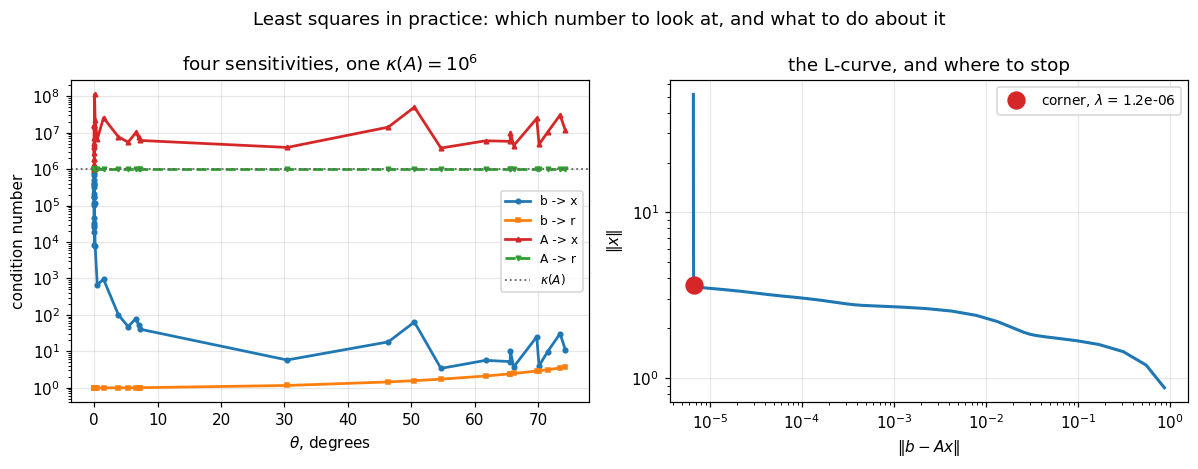

In [15]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4.3))

# left: the four condition numbers as the angle grows
angles, curves = [], {"b -> x": [], "b -> r": [], "A -> x": [], "A -> r": []}
for level in np.geomspace(1e-8, 30.0, 40):
    b_f = (A_c @ rng.standard_normal(A_c.shape[1])
           + level * rng.standard_normal(A_c.shape[0]))
    info = ls.least_squares_conditioning(A_c, b_f)
    angles.append(np.degrees(info["theta"]))
    for key in curves:
        curves[key].append(info[key.replace(" -> ", "_to_")])
order = np.argsort(angles)
for key, style in [("b -> x", "C0o-"), ("b -> r", "C1s-"),
                   ("A -> x", "C3^-"), ("A -> r", "C2v--")]:
    axL.semilogy(np.array(angles)[order], np.array(curves[key])[order], style,
                 lw=1.8, ms=3, label=key)
axL.axhline(np.linalg.cond(A_c), color="0.4", lw=1.2, ls=":", label=r"$\kappa(A)$")
axL.set_xlabel(r"$\theta$, degrees")
axL.set_ylabel("condition number")
axL.set_title(r"four sensitivities, one $\kappa(A) = 10^6$")
axL.legend(fontsize=8)

# right: the L-curve, with its corner
axR.loglog(curve["residual_norms"], curve["solution_norms"], "C0-", lw=2)
axR.plot(curve["residual_norms"][curve["corner_index"]],
         curve["solution_norms"][curve["corner_index"]], "C3o", ms=11,
         label=f"corner, $\\lambda$ = {curve['corner_lambda']:.1e}")
axR.set_xlabel(r"$\|b - Ax\|$")
axR.set_ylabel(r"$\|x\|$")
axR.set_title("the L-curve, and where to stop")
axR.legend(fontsize=9)

fig.suptitle("Least squares in practice: which number to look at, and what to do about it",
             fontsize=12)
fig.tight_layout()
plt.show()

**The left panel is the lesson.** One matrix, one $\kappa$, and four curves spanning seven
orders of magnitude as the data moves relative to the model. Only the flat one equals $\kappa$.

---

## 9. Exercises

**Level 1, conceptual**

1.1 Why does the sensitivity to $A$ carry a $\kappa^2$ while the sensitivity to $\mathbf{b}$
does not?

1.2 A rank deficient least squares problem has infinitely many solutions with the same residual.
Why is picking the smallest one a choice rather than a consequence?

1.3 The SVD gave a worse answer than QR at $\kappa = 10^{14}$. What happened, and was either of
them wrong?

**Level 2, mathematical**

2.1 Derive the four condition numbers of section 1 from the SVD, and identify exactly where
$\theta$ and $\eta$ enter.

2.2 Prove that $A^+ = V\Sigma^+U^T$ satisfies all four Penrose conditions, and that they
determine it uniquely.

2.3 Show that Tikhonov regularization replaces $1/\sigma_i$ by $\sigma_i/(\sigma_i^2+\lambda^2)$,
and that $\lim_{\lambda\to0} \mathbf{x}_\lambda = A^+\mathbf{b}$.

2.4 Prove that the augmented system $[A;\lambda I]$ has condition number
$\sqrt{(\sigma_1^2+\lambda^2)/(\sigma_n^2+\lambda^2)}$, and hence that regularization improves
the conditioning as well as the answer.

2.5 Show that $\eta$ satisfies $1 \le \eta \le \kappa$, and describe the matrices at each end.

**Level 3, computational**

3.1 Implement **generalised cross validation** to choose $\lambda$, and compare it against the
L-curve on problems where the true answer is known. Which lands closer, and how often?

3.2 Implement **Tikhonov with a general regularizer** $\|L\mathbf{x}\|$ rather than
$\|\mathbf{x}\|$, with $L$ a first or second difference operator. Show that it prefers smooth
solutions rather than small ones, and find a problem where that is clearly the right choice.

3.3 Implement the **bidiagonalization** route to least squares: reduce $A$ to bidiagonal form
with Householder reflectors from both sides, then solve. Compare its cost and accuracy against
QR and the full SVD.

**Level 4, experimental**

4.1 Measure all four condition numbers against $\theta$ over its whole range, on matrices of
several $\kappa$, and confirm the formulas. Then measure the achieved sensitivity and fit the
ratio.

4.2 Sweep the SVD's `rcond` over many decades on a problem with a known answer, and find the
value minimising the error. Compare it with the default, and explain any gap.

4.3 Construct problems whose singular values do and do not have a gap, and compare truncation
against Tikhonov on both. Confirm that they agree in the first case and diverge in the second.

**Level 5, advanced**

5.1 **The statistical reading of regularization.** Show that Tikhonov is the maximum a
posteriori estimate under a Gaussian prior on $\mathbf{x}$, identify what $\lambda$ corresponds
to, and explain what that says about choosing it.

5.2 **The discrete Picard condition.** For a genuinely ill posed problem, the coefficients
$|\mathbf{u}_i^T\mathbf{b}|$ must decay faster than $\sigma_i$ for a useful solution to exist.
State it, test it on a discretised integral equation, and relate it to where the L-curve corner
lands.

5.3 **Why not always use the SVD.** It is the most robust of the three and the most expensive.
Work out where the cost actually matters, including the case of many right-hand sides and the
case where $A$ changes slightly between solves, and identify what QR offers that the SVD does
not.

## 10. Key takeaways

- **There are four condition numbers, not one.** Measured on a single matrix with
  $\kappa = 10^{6}$: the four range over **seven orders of magnitude** as the data moves
  relative to the model, and only the sensitivity of the residual to $A$ equals $\kappa$.
- **The angle $\theta$ decides which regime you are in**, and it is free: $\sin\theta$ is the
  relative residual, verified to nine digits. Look at it before deciding a problem is hard.
- **Compute $\theta$ with `arctan2`, not `arccos`.** Measured over relative residuals
  from $10^{-11}$ to 1: below about $10^{-8}$ the arccos form returns **exactly
  zero**, a 100 percent error, while arctan2 stays below $10^{-12}$ throughout. The
  derivative of arccos is infinite exactly where its argument sits.
- **The $\kappa^2$ is real when the residual is large.** It is a property of the problem, not an
  artefact of the normal equations, so no algorithm removes it.
- **The bound overstates a random perturbation by a factor of 8 to 24**, roughly $\sqrt{m}$,
  because a random direction puts only $1/\sqrt{m}$ of itself along the worst one. Plan for the
  bound; expect the measurement.
- **The pseudoinverse satisfies all four Penrose conditions to $10^{-13}$**, for tall, wide,
  full rank and rank deficient alike, and the two symmetry conditions are what make it unique.
- **The minimum norm solution is a choice.** Measured: adding any multiple of a null vector
  leaves the residual identical to six decimals, so the least squares condition does not choose
  between them.
- **The SVD can be worse than QR.** Measured at $\kappa = 10^{14}$: three orders of magnitude
  worse, because its threshold declared the matrix rank 7 and discarded a direction the answer
  needed. The threshold is a judgement and it can err in either direction.
- **On a genuinely rank deficient problem the three behave completely differently.** QR refuses,
  the SVD reports the right rank and returns the minimum norm answer, and the normal equations
  report the **wrong rank** and hand back a number. The last is the dangerous one.
- **Regularization changes the problem**, and an unregularized answer on an ill posed problem was
  measured at **29 times** the size of the truth and 32 times as wrong. Say in the write-up
  that the answer is regularized.
- **The L-curve chooses $\lambda$ from computable quantities alone** and landed within a factor
  of 1.4 of the penalty that needed the answer, at the same error to two decimal places.
- **And regularization does not create information.** Even the best penalty left a relative error
  around 0.5, because at $\kappa = 10^{8}$ with noise at $10^{-6}$ the data does not determine
  the answer.

## Where this goes next

**Lesson 33** takes up the question this lesson kept deferring: how to decide the rank. QR with
column pivoting reveals it more cheaply than the SVD, "numerical rank" needs a definition rather
than a threshold pulled from the air, and total least squares handles the case where the errors
are in $A$ as well as in $\mathbf{b}$.

**Lesson 34** drops linearity in the parameters, where Gauss-Newton and Levenberg-Marquardt take
over and the regularization idea of section 6 reappears as the Levenberg damping.

**Lesson 41** builds the SVD rather than calling it, and explains why computing it through the
eigenvalues of $A^TA$ would repeat lesson 29's mistake.

Solutions are in [`solutions/part05_least_squares_and_qr.md`](../solutions/part05_least_squares_and_qr.md).